In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [5]:
# Parameters
K = 100       # Strike
r = 0.05       # Risk-free interest rate
sigma = 0.2    # Volatility
higher_sigma = 0.7
# Underlying price range
S0 = np.linspace(60, 140, 500)

# Time to maturities in years
T_values = [1/12, 0.5, 1, 5]  # 1 month, 6 months, 1 year

def european_option_price(S0, K, T, r, sigma, q=0, option_type='call'):
    # Calculate d1 and d2
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Call option pricing formulaíí
    if option_type == 'call':
        option_price = S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    # Put option pricing formula
    elif option_type == 'put':
        option_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    return option_price

def european_digital_option_price(S0, K, T, r, sigma, q=0, option_type='call'):

    d2 = (np.log(S0 / K) + (r - q - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    
    if option_type == 'call':
        return np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        return np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

def reflection_b_less_than_k(S0, K, T, r, sigma, B, q=0):
    multiplier = (S0/B)** (1-2*(r-q)/(sigma**2))
    res = np.where(S0>B, 
                   european_option_price(S0, K, T, r, sigma) - ( multiplier )*european_option_price((B**2)/S0, K, T, r, sigma) , 
                   0)
    return res

def reflection_b_grtr_than_k(S0, K, T, r, sigma, B, q=0):
    multiplier = (S0/B)**( 1-2*(r-q)/(sigma**2) )
    res = np.where(S0>B,
                   (
                       european_option_price(S0, B, T, r, sigma) + (B-K)*european_digital_option_price(S0, B, T, r, sigma)
                       - multiplier*(european_option_price((B**2)/S0, B, T, r, sigma) + (B-K)*european_digital_option_price((B**2)/S0, B, T, r, sigma)) 
                   ), 
                   0)
    return res

def reflection_barrier(S0, K, T, r, sigma, B, q=0):
    if B<K:
        return reflection_b_less_than_k(S0, K, T, r, sigma, B, q)
    else:
        return reflection_b_grtr_than_k(S0, K, T, r, sigma, B, q)

def reflection_barrier_di(S0, K, T, r, sigma, B, q=0):
    return european_option_price(S0, K, T, r, sigma) - reflection_barrier(S0, K, T, r, sigma, B, q=0)

def barrier_delta_numeric_di(S0, K, T, r, sigma, B, q=0, h=0.001):
    
    price_up = reflection_barrier_di(S0+h, K, T, r, sigma, B, q)
    price_down = reflection_barrier_di(S0-h, K, T, r, sigma, B, q)
    
    derivative = (price_up - price_down) / (2 * h)
    return derivative

def barrier_vega_numeric_di(S0, K, T, r, sigma, B, q=0, h=0.001):
    
    price_up = reflection_barrier_di(S0, K, T, r, sigma+h, B, q)
    price_down = reflection_barrier_di(S0, K, T, r, sigma-h, B, q)
    
    derivative = (price_up - price_down) / (2 * h)
    return derivative
    
def barrier_delta_numeric(S0, K, T, r, sigma, B, q=0, h=0.001):
    
    price_up = reflection_barrier(S0+h, K, T, r, sigma, B, q)
    price_down = reflection_barrier(S0-h, K, T, r, sigma, B, q)
    
    derivative = (price_up - price_down) / (2 * h)
    return derivative

def barrier_vega_numeric(S0, K, T, r, sigma, B, q=0, h=0.001):
    
    price_up = reflection_barrier(S0, K, T, r, sigma+h, B, q)
    price_down = reflection_barrier(S0, K, T, r, sigma-h, B, q)
    
    derivative = (price_up - price_down) / (2 * h)
    return derivative

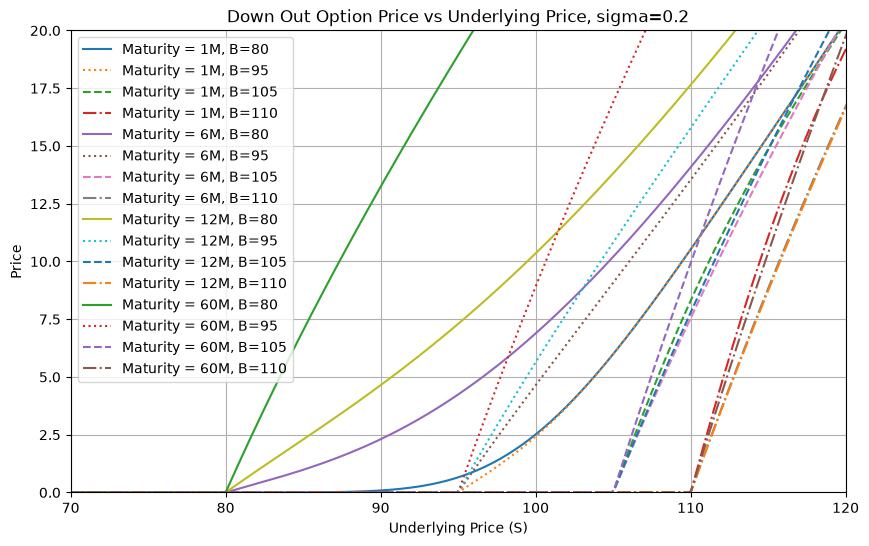

In [6]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    B=80
    delta = reflection_barrier(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=95
    delta = reflection_barrier(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle=':', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=105
    delta = reflection_barrier(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='--', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=110
    delta = reflection_barrier(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-.', label=f'Maturity = {T*12:.0f}M, B={B}')

plt.xlim(70, 120)
plt.ylim(0, 20)

# Customizing plot
plt.title(f"Down Out Option Price vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

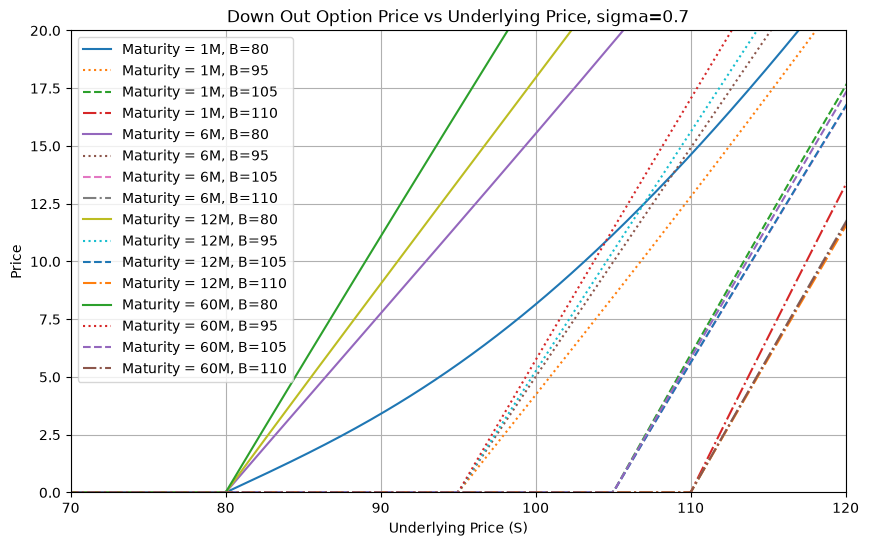

In [7]:
higher_sigma=0.7
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    B=80
    delta = reflection_barrier(S0, K, T, r, higher_sigma, B)
    plt.plot(S0, delta, linestyle='-', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=95
    delta = reflection_barrier(S0, K, T, r, higher_sigma, B)
    plt.plot(S0, delta, linestyle=':', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=105
    delta = reflection_barrier(S0, K, T, r, higher_sigma, B)
    plt.plot(S0, delta, linestyle='--', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=110
    delta = reflection_barrier(S0, K, T, r, higher_sigma, B)
    plt.plot(S0, delta, linestyle='-.', label=f'Maturity = {T*12:.0f}M, B={B}')
    
plt.xlim(70, 120)
plt.ylim(0, 20)
# Customizing plot
plt.title(f"Down Out Option Price vs Underlying Price, sigma={higher_sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

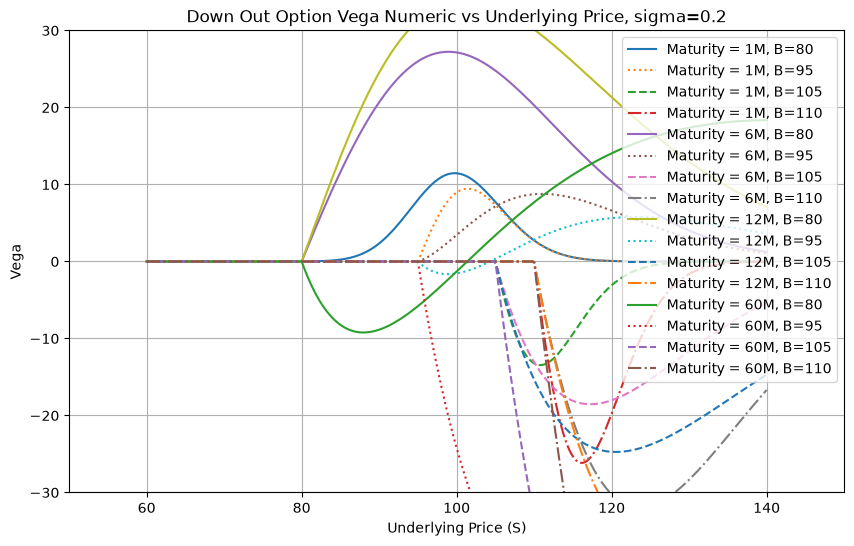

In [8]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    B=80
    delta = barrier_vega_numeric(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=95
    delta = barrier_vega_numeric(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle=':', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=105
    delta = barrier_vega_numeric(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='--', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=110
    delta = barrier_vega_numeric(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-.', label=f'Maturity = {T*12:.0f}M, B={B}')
    
plt.xlim(50, 150)
plt.ylim(-30, 30)
# Customizing plot
plt.title(f"Down Out Option Vega Numeric vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Vega")
plt.legend()
plt.grid(True)
plt.show()

# Vega (sensitivity to vol) is negative when large TTM and near Barrier because Option has time to KO. 
# but as TTM goes down and further out of B - changes in vol don't effect chances of hitting Barrier that much. So Vega converges to that of a European. 
# Vega is 0 around Barrier (since PRICE is also near 0 around Barrier), but high around Strike
# When SIGNIFICANTLY above B (and therefore further ITM or closer to being ITM) and low TTM - VOL is GOOD
# But when ALOT of TTM and close to Barrier - VOL is BAD

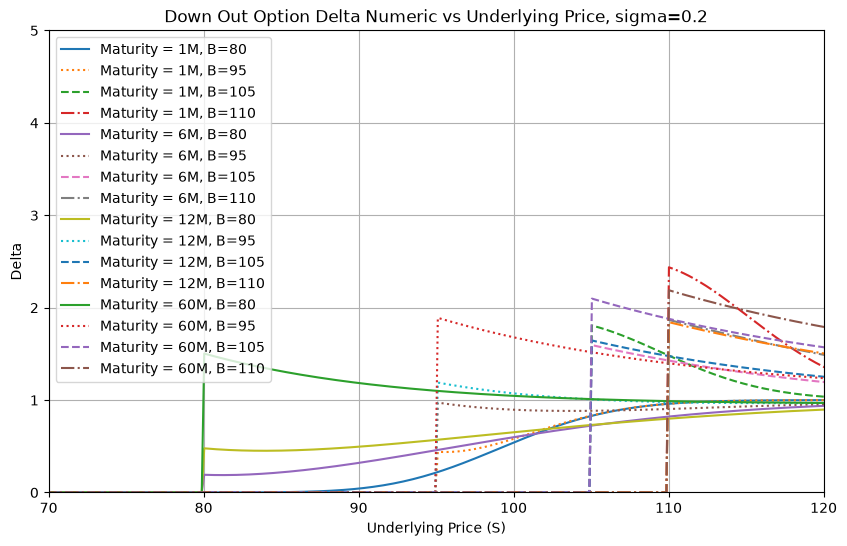

In [9]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    B=80
    delta = barrier_delta_numeric(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=95
    delta = barrier_delta_numeric(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle=':', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=105
    delta = barrier_delta_numeric(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='--', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=110
    delta = barrier_delta_numeric(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-.', label=f'Maturity = {T*12:.0f}M, B={B}')
    
plt.xlim(70, 120)
plt.ylim(0, 5)
# Customizing plot
plt.title(f"Down Out Option Delta Numeric vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

# Barrier DI

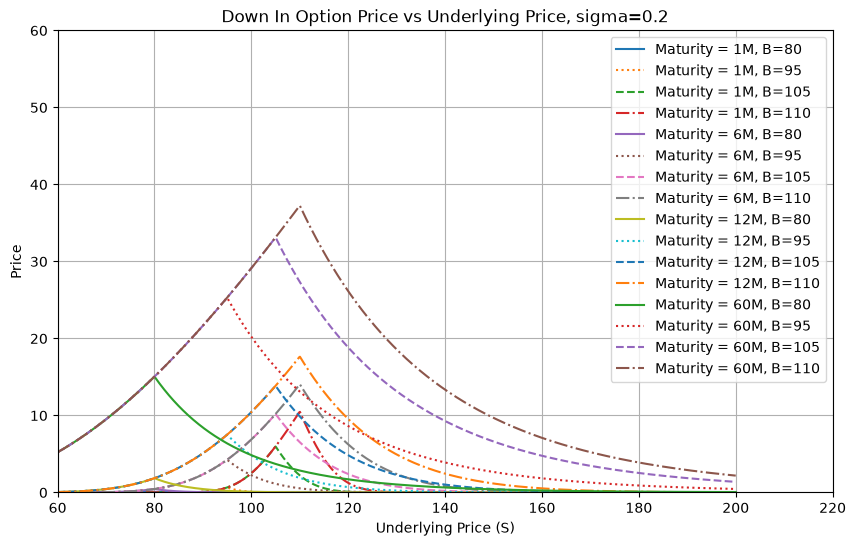

In [10]:
S0 = np.linspace(60, 200, 1000)

# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    B=80
    delta = reflection_barrier_di(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=95
    delta = reflection_barrier_di(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle=':', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=105
    delta = reflection_barrier_di(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='--', label=f'Maturity = {T*12:.0f}M, B={B}')
    B=110
    delta = reflection_barrier_di(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-.', label=f'Maturity = {T*12:.0f}M, B={B}')

plt.xlim(60, 220)
plt.ylim(0, 60)

# Customizing plot
plt.title(f"Down In Option Price vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

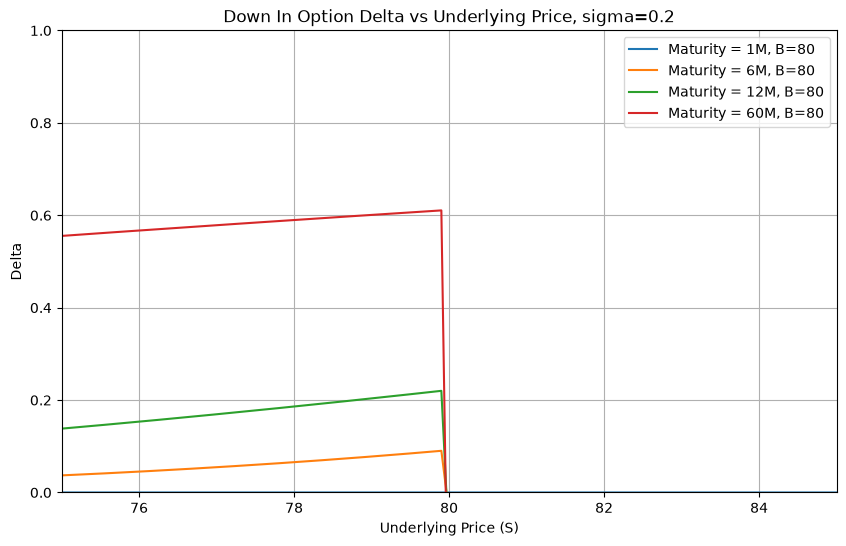

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    B=80
    delta = barrier_delta_numeric_di(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-', label=f'Maturity = {T*12:.0f}M, B={B}')
    # B=95
    # delta = barrier_delta_numeric_di(S0, K, T, r, sigma, B)
    # plt.plot(S0, delta, linestyle=':', label=f'Maturity = {T*12:.0f}M, B={B}')
    # B=105
    # delta = barrier_delta_numeric_di(S0, K, T, r, sigma, B)
    # plt.plot(S0, delta, linestyle='--', label=f'Maturity = {T*12:.0f}M, B={B}')
    # B=110
    # delta = barrier_delta_numeric_di(S0, K, T, r, sigma, B)
    # plt.plot(S0, delta, linestyle='-.', label=f'Maturity = {T*12:.0f}M, B={B}')

plt.xlim(75, 85)
plt.ylim(0, 1)

# Customizing plot
plt.title(f"Down In Option Delta vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

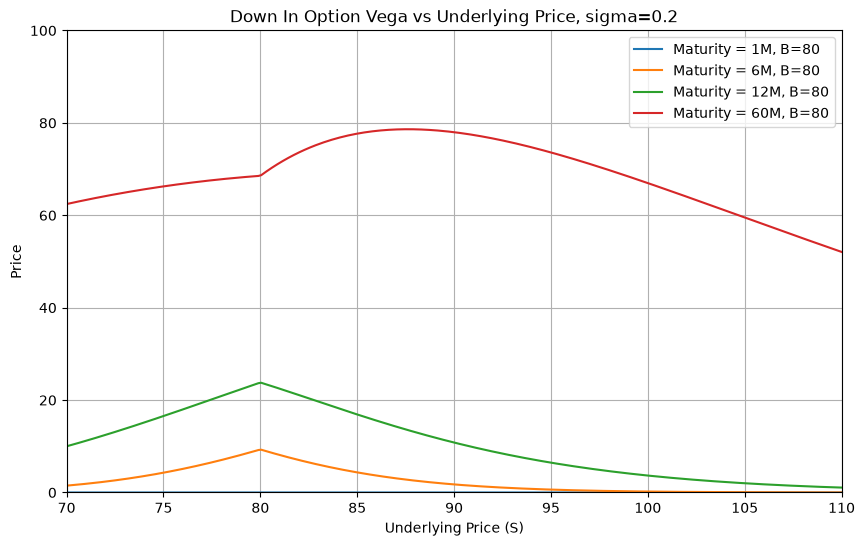

In [12]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    B=80
    delta = barrier_vega_numeric_di(S0, K, T, r, sigma, B)
    plt.plot(S0, delta, linestyle='-', label=f'Maturity = {T*12:.0f}M, B={B}')
    

plt.xlim(70, 110)
plt.ylim(0, 100)

# Customizing plot
plt.title(f"Down In Option Vega vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()